## SQL Interview Prep — Theory & Approaches

Companion notes for [06-sql-by-pattern.ipynb](06-sql-by-pattern.ipynb). That notebook stays limited to **Question → Proposed Solution** pairs; the pattern write-ups, multi-approach comparisons, and worked examples that used to sit alongside those questions live here instead.

<a id="toc"></a>

### Table of Contents

- [Gaps & Islands (Streaks)](#gaps-islands-streaks)
- [Finding and Removing Duplicate Values](#finding-removing-duplicate-values)
- [Period Over Period Comparion](#period-over-period)
- [Running Total and Cumulative Distributiones](#running-totals-and-cumulative-calculations)
- [Gaps in Sequence](#gaps-in-sequences)
- [Funnel Analysis, Cohorts, and Retention](#funnel-analysis-cohorts)
- [Median and Percentile Calculations](#median-and-percentile-calculations)

<a id="gaps-islands-streaks"></a>

## Gaps & Islands (Streaks)

[↑ Back to top](#toc)


"find users who were active on 3 or more consecutive days," "identify tracks in a row with the same duration," or "find each user's longest daily streak." 

"Consecutive" in SQL means rows that form an unbroken sequence when ordered by some column. The sequence might be dates (daily login streaks), integers (track numbers on an album)

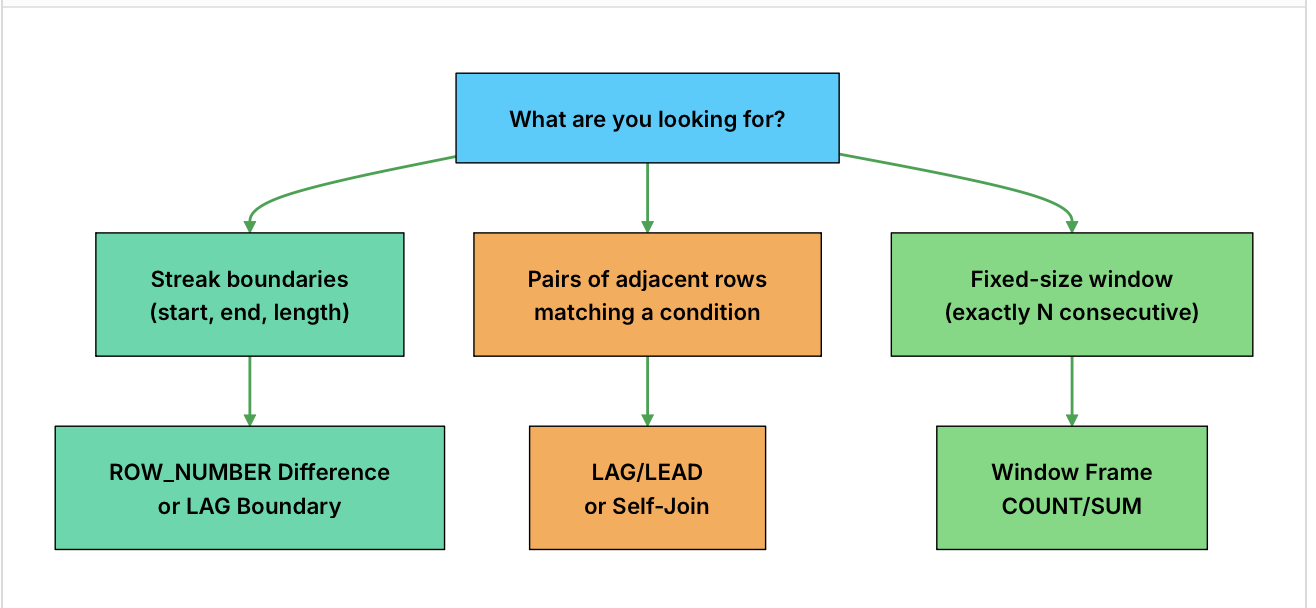

### Approach 1: ROW_NUMBER Difference

The short version: assign a ROW_NUMBER to each row within a partition, subtract it from the sequence value (date or integer), and rows in the same consecutive run share the same difference. That difference becomes a group key.

```sql
WITH daily_streams AS (
    SELECT DISTINCT
           user_id,
           started_at::DATE AS stream_date
    FROM streams
),
numbered AS (
    SELECT user_id,
           stream_date,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY stream_date) AS rn
    FROM daily_streams
),
grouped AS (
    SELECT user_id,
           stream_date,
           stream_date - (rn * INTERVAL '1 day') AS group_key
    FROM numbered
),
streaks AS (
    SELECT user_id,
           MIN(stream_date) AS streak_start,
           MAX(stream_date) AS streak_end,
           COUNT(*)         AS streak_days
    FROM grouped
    GROUP BY user_id, group_key
)
SELECT u.username,
       s.streak_start,
       s.streak_end,
       s.streak_days
FROM streaks s
JOIN users u ON u.user_id = s.user_id
WHERE s.streak_days >= 3
ORDER BY u.username, s.streak_start;
```

Integer Sequences - For integer columns like track_number, the subtraction is simpler because you skip the interval arithmetic:

```sql
WITH numbered AS (
    SELECT album_id,
           track_number,
           title,
           ROW_NUMBER() OVER (PARTITION BY album_id ORDER BY track_number) AS rn
    FROM tracks
)
SELECT album_id,
       MIN(track_number) AS seq_start,
       MAX(track_number) AS seq_end,
       COUNT(*)          AS seq_length
FROM numbered
GROUP BY album_id, track_number - rn
-- The expression track_number - rn works directly because both are integers
-- If track numbers run 1, 2, 3, 5, 6, the group keys would be 0, 0, 0, 1, 1
-- producing two islands: [1-3] and [5-6].
ORDER BY album_id, seq_start;
```



### Approach 2: LAG-Based Boundary Detection

Instead of computing a group key from ROW_NUMBER, you can use LAG to compare each row with its predecessor. When the gap between consecutive rows exceeds the expected step (1 day, 1 integer), that row starts a new streak. A running SUM of those boundary markers produces group IDs.

```sql
WITH daily_streams AS (
    SELECT DISTINCT
           user_id,
           started_at::DATE AS stream_date
    FROM streams
),
with_lag AS (
    SELECT user_id,
           stream_date,
           LAG(stream_date) OVER (PARTITION BY user_id ORDER BY stream_date) AS prev_date
    FROM daily_streams
),
boundaries AS (
    SELECT user_id,
           stream_date,
           CASE
               WHEN prev_date IS NULL THEN 1
               WHEN stream_date - prev_date > 1 THEN 1
               ELSE 0
           END AS new_streak
    FROM with_lag
),
grouped AS (
    SELECT user_id,
           stream_date,
           SUM(new_streak) OVER (PARTITION BY user_id ORDER BY stream_date) AS streak_id
    FROM boundaries
)
SELECT user_id,
       MIN(stream_date) AS streak_start,
       MAX(stream_date) AS streak_end,
       COUNT(*)         AS streak_days
FROM grouped
GROUP BY user_id, streak_id
ORDER BY user_id, streak_start;
```


**Consecutive Matching with LAG** - LAG is particularly natural for problems where consecutive rows must share a property, not just be adjacent. For example, finding consecutive tracks on the same album with the same duration

```sql
WITH with_prev AS (
    SELECT album_id,
           track_number,
           title,
           duration_seconds,
           LAG(duration_seconds) OVER (
               PARTITION BY album_id ORDER BY track_number
           ) AS prev_duration,
           LAG(track_number) OVER (
               PARTITION BY album_id ORDER BY track_number
           ) AS prev_track_number
    FROM tracks
)
SELECT album_id,
       track_number,
       title,
       duration_seconds
FROM with_prev
WHERE duration_seconds = prev_duration
  AND track_number = prev_track_number + 1;
```


### Approach 3 : Self-Join

Each join adds one more day to the chain. The first join connects day N to day N+1. The second connects day N to day N+2. If all three joins succeed, the user had three consecutive streaming days starting from d1.stream_date.

The downside is that each additional day requires another join.  Self-joins still come up in interviews as a follow-up: "How would you solve this without window functions?"

```sql
WITH daily_streams AS (
    SELECT DISTINCT
           user_id,
           started_at::DATE AS stream_date
    FROM streams
)
SELECT DISTINCT d1.user_id
FROM daily_streams d1
JOIN daily_streams d2
    ON d2.user_id = d1.user_id
   AND d2.stream_date = d1.stream_date + 1
JOIN daily_streams d3
    ON d3.user_id = d1.user_id
   AND d3.stream_date = d1.stream_date + 2
ORDER BY d1.user_id;
```

### Approach 4: Window Frame Counting

When the problem asks "find rows where the last N consecutive rows all satisfy a condition," window frames offer a compact solution. Instead of grouping rows into streaks and filtering by length, you check a fixed-size sliding window directly.

Finding user who have consecutive payment subscription for 3 Months

The window frame RANGE BETWEEN INTERVAL '2 months' PRECEDING AND CURRENT ROW looks at the current month and the two months before it. If all three months have data, the COUNT is 3. 

Be careful with the frame type. ROWS BETWEEN 2 PRECEDING AND CURRENT ROW counts exactly 3 rows regardless of whether they represent consecutive months. If a user skipped a month, the 3 rows might span 4 calendar months

```sql
WITH monthly_payments AS (
    SELECT DISTINCT
           user_id,
           DATE_TRUNC('month', payment_date) AS payment_month
    FROM payments
    WHERE status = 'completed'
),
with_count AS (
    SELECT user_id,
           payment_month,
           COUNT(*) OVER (
               PARTITION BY user_id
               ORDER BY payment_month
               RANGE BETWEEN INTERVAL '2 months' PRECEDING AND CURRENT ROW
           ) AS months_in_window
    FROM monthly_payments
)
SELECT DISTINCT user_id
FROM with_count
WHERE months_in_window = 3;
```

---

<a id="finding-removing-duplicate-values"></a>

## Finding and Removing Duplicate Values

[↑ Back to top](#toc)


Detect answers "are there duplicates at all?" using GROUP BY + HAVING. Identify answers "which specific rows are the duplicates?" using self-joins or window functions. Choose answers "which row in each group should survive? based on a strategy like keeping the first, the latest, or the one with the most data. Remove either filters them from a SELECT result or physically DELETEs them from the table.

### Approach 1: GROUP BY + HAVING (Detection)

Suppose a stream should be unique on the combination of user_id, track_id, and started_at. Any group with more than one row represents a duplicate:

```sql
SELECT user_id, track_id, started_at, COUNT(*) AS occurrence_count
FROM streams
GROUP BY user_id, track_id, started_at
HAVING COUNT(*) > 1;
```

Email addresses are a common source of duplicates because and refer to the same mailbox. PostgreSQL's default collation treats them as different strings, so a plain GROUP BY misses them:

```sql

-- This misses case-variant duplicates
SELECT email, COUNT(*) AS occurrence_count
FROM users
GROUP BY email
HAVING COUNT(*) > 1;
```

Sometimes "duplicate" means "same user and track on the same day" rather than an exact timestamp match. Use DATE() to truncate timestamps before grouping:

```sql
SELECT user_id, track_id, DATE(started_at) AS stream_date, COUNT(*) AS occurrence_count
FROM streams
GROUP BY user_id, track_id, DATE(started_at)
HAVING COUNT(*) > 1;
```

Before jumping into cleanup, it helps to know the scale of the problem. How many duplicate groups exist, and how many excess rows need to be removed?

```sql
WITH duplicates AS (
    SELECT user_id, track_id, started_at, COUNT(*) AS occurrence_count
    FROM streams
    GROUP BY user_id, track_id, started_at
    HAVING COUNT(*) > 1
)
SELECT
    COUNT(*) AS duplicate_groups,
    SUM(occurrence_count - 1) AS excess_rows -- occurrence_count - 1 gives the number of extra rows per group (if a group has 3 rows, 2 are excess).
FROM duplicates;
```

The same detection logic in pandas, using `groupby().size()` in place of `GROUP BY` + `COUNT(*)` and boolean filtering in place of `HAVING`:

```python
dupe_groups = (streams.groupby(["user_id", "track_id", "started_at"])
               .size()
               .rename("occurrence_count")
               .reset_index())
dupe_groups = dupe_groups[dupe_groups["occurrence_count"] > 1]

# Case-variant emails
email_dupes = (users.assign(email=users["email"].str.lower())
               .groupby("email").size()
               .rename("occurrence_count").reset_index())
email_dupes = email_dupes[email_dupes["occurrence_count"] > 1]

# Same day rather than exact timestamp
day_dupes = (streams.assign(stream_date=streams["started_at"].dt.date)
             .groupby(["user_id", "track_id", "stream_date"]).size()
             .rename("occurrence_count").reset_index())
day_dupes = day_dupes[day_dupes["occurrence_count"] > 1]

# Scale of the problem
duplicate_groups = len(dupe_groups)
excess_rows = (dupe_groups["occurrence_count"] - 1).sum()
```
---

### Approach 3: ROW_NUMBER (Deduplication via SELECT)

ROW_NUMBER assigns a sequential number to each row within a partition. If you partition by the columns that define a duplicate group and order by your preferred "keep" criteria, row number 1 is always the keeper. Filter to rn = 1 and you get a clean, deduplicated result set.

The most common strategy is to keep the row with the lowest primary key, treating it as the first one inserted:

```sql
WITH numbered AS (
    SELECT
        stream_id,
        user_id,
        track_id,
        started_at,
        duration_listened,
        ROW_NUMBER() OVER (
            PARTITION BY user_id, track_id, started_at
            ORDER BY stream_id
        ) AS rn
    FROM streams
)
SELECT stream_id, user_id, track_id, started_at, duration_listened
FROM numbered
WHERE rn = 1;
```

If you want the most recent entry instead (e.g., the latest version of a record after corrections):
```sql
WITH numbered AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY user_id, track_id, started_at
            ORDER BY stream_id DESC
        ) AS rn
    FROM streams
)
SELECT *
FROM numbered
WHERE rn = 1;
-- Changing ORDER BY stream_id to ORDER BY stream_id DESC makes the highest stream_id (most recently inserted) get rn = 1.

```

Sometimes the "best" row is not the first or last, but the one with the most complete data. For streams, you might want to keep the row where the user listened the longest:

```sql
WITH numbered AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY user_id, track_id, started_at
            ORDER BY duration_listened DESC NULLS LAST, stream_id
        ) AS rn
    FROM streams
)
SELECT *
FROM numbered
WHERE rn = 1;

-- The ORDER BY has two parts. duration_listened DESC NULLS LAST ranks rows by listening duration, putting the longest listen first and pushing NULLs to the end. stream_id is a tiebreaker: if two rows have the same duration, the one with the lower stream_id wins. Without a tiebreaker, ROW_NUMBER picks arbitrarily among tied rows, which makes the result nondeterministic.

```
The PARTITION BY clause can include any expression, not just raw columns. To deduplicate by user, track, and date (ignoring exact timestamps):

```sql
WITH numbered AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY user_id, track_id, DATE(started_at)
            ORDER BY started_at, stream_id
        ) AS rn
    FROM streams
)
SELECT *
FROM numbered
WHERE rn = 1;
```

`ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)` maps onto `sort_values()` + `groupby().cumcount()` in pandas: sort so the row you want to keep comes first within each group, then take the first row per group with `groupby(...).head(1)` (equivalent to filtering `rn == 1`, without needing to materialize the rank column at all):

```python
# Keep the lowest stream_id per group (first inserted)
dedup_first = (streams.sort_values(["user_id", "track_id", "started_at", "stream_id"])
               .groupby(["user_id", "track_id", "started_at"])
               .head(1))

# Keep the highest stream_id per group (most recent)
dedup_latest = (streams.sort_values(["user_id", "track_id", "started_at", "stream_id"],
                                     ascending=[True, True, True, False])
                .groupby(["user_id", "track_id", "started_at"])
                .head(1))

# Keep the row with the longest duration_listened, tiebreak by stream_id
dedup_longest = (streams.sort_values(
                     ["user_id", "track_id", "started_at", "duration_listened", "stream_id"],
                     ascending=[True, True, True, False, True],
                     na_position="last")
                 .groupby(["user_id", "track_id", "started_at"])
                 .head(1))

# Deduplicate by user, track, and calendar date rather than exact timestamp
dedup_by_day = (streams.assign(stream_date=streams["started_at"].dt.date)
                .sort_values(["user_id", "track_id", "stream_date", "started_at", "stream_id"])
                .groupby(["user_id", "track_id", "stream_date"])
                .head(1))
```

### Approach 4: DELETE with CTE + ROW_NUMBER

CTE + DELETE

```sql
WITH numbered AS (
    SELECT stream_id,
        ROW_NUMBER() OVER (
            PARTITION BY user_id, track_id, started_at
            ORDER BY stream_id
        ) AS rn
    FROM streams
)
DELETE FROM streams
WHERE stream_id IN (
    SELECT stream_id FROM numbered WHERE rn > 1
);
```

SELF JOIN

```sql
DELETE FROM streams s1
USING streams s2
WHERE s1.user_id = s2.user_id
  AND s1.track_id = s2.track_id
  AND s1.started_at = s2.started_at
  AND s1.stream_id > s2.stream_id;
```

There's no `DELETE` in pandas since a DataFrame isn't a persistent table — "removing duplicates" just means reassigning the deduplicated result back to the variable, which is what `Approach 3` already produces:

```python
streams = (streams.sort_values(["user_id", "track_id", "started_at", "stream_id"])
           .groupby(["user_id", "track_id", "started_at"])
           .head(1)
           .reset_index(drop=True))
```


### NULLs in Duplicate Keys
Two NULLs are not equal in standard SQL. The expression NULL = NULL evaluates to NULL (not TRUE), so a JOIN condition like s1.country = s2.country does not match two rows where country is NULL.

PostgreSQL's GROUP BY and PARTITION BY are an exception: they treat NULLs as belonging to the same group. This means ROW_NUMBER with PARTITION BY country puts all NULL-country rows into one partition. But a self-join on s1.country = s2.country does not pair those same rows.

pandas follows the GROUP BY/PARTITION BY convention, not the join convention: `groupby("country")` puts every `NaN`-country row into its own group together (by default, recent pandas versions include `NaN` as a group rather than dropping it), matching `PARTITION BY`. But `merge(df, df, on="country")` — pandas's self-join — does **not** match `NaN` to `NaN`, the same gap that exists in SQL.

### Large Duplicate Sets
When a single duplicate group contains thousands of rows (a bulk import that ran twice, for example), the approach matters:

Self-join: Produces N*(N-1)/2 pairs. For 10,000 duplicates, that is ~50 million pairs from one group alone. This can exhaust memory or take a very long time.
ROW_NUMBER: Processes each row independently within the partition. 10,000 rows produce 10,000 numbered rows. Linear, not quadratic.

The same asymmetry holds in pandas: a self-`merge` materializes the full N×N cross product within each matching key before you can filter it down, while `sort_values().groupby().cumcount()` (or `.head(1)`) processes each row once, linear in the number of rows.

<a id="period-over-period"></a>

## Period Over Period Comparisons
[↑ Back to top](#toc)

1. Aggregate raw data into periods. Turn individual rows into one row per time bucket (month, quarter, year) with the metric you care about (stream count, revenue, user count).

2. Compare each period to a prior period. Pull the previous period's value alongside the current one, then compute the delta or growth percentage.

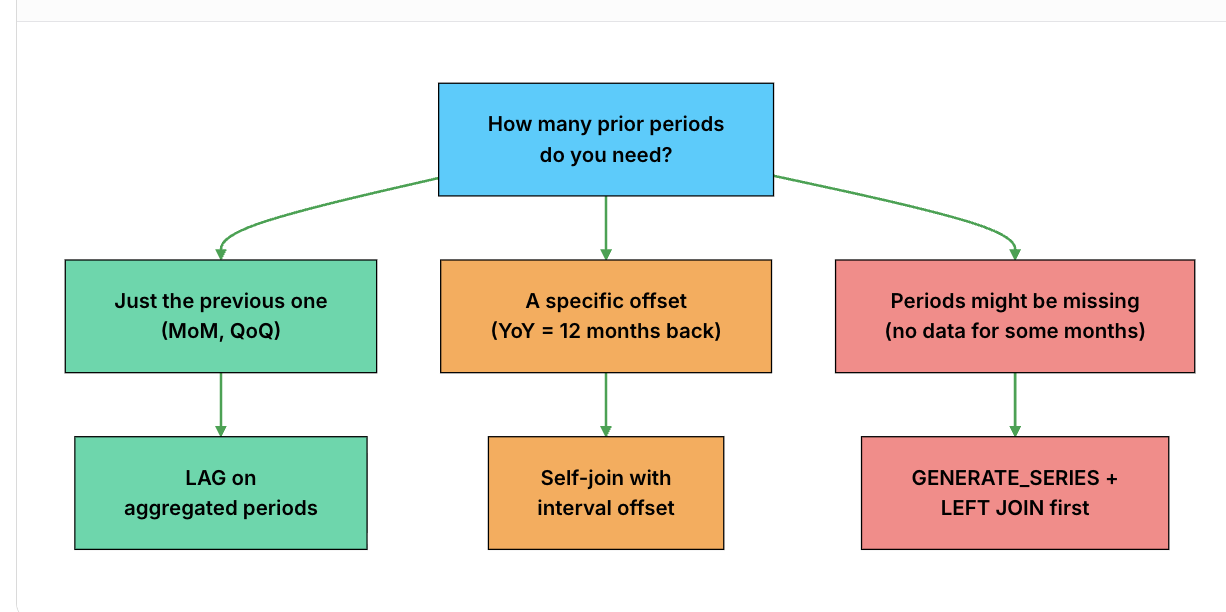

 ### Approach 1: LAG on Aggregated Periods

Aggregate your data into monthly (or quarterly, yearly) buckets, then use LAG to pull the previous period's value into the current row.

```sql
WITH monthly_streams AS (
    SELECT DATE_TRUNC('month', started_at)::DATE AS month, 
           COUNT(*) AS stream_count
    FROM streams
    GROUP BY DATE_TRUNC('month', started_at)
)
SELECT month,
       stream_count,
       LAG(stream_count) OVER (ORDER BY month) AS prev_month_streams, 
       -- grabs previous value when rows are ordered by month
       stream_count - LAG(stream_count) OVER (ORDER BY month) AS abs_change,
       ROUND(
           (stream_count - LAG(stream_count) OVER (ORDER BY month))
           * 100.0
           / LAG(stream_count) OVER (ORDER BY month),
           1
       ) AS pct_change
       -- current - previous / previous * 100
FROM monthly_streams
ORDER BY month;

```

#### Adding Dimension Breakdown.

```sql
    LAG(stream_count) OVER (PARTITION BY genre ORDER BY month) AS prev_month,
    -- Resets the lag for each genere, Without it, LAG would compare someone else category
```
[!NOTE]
    The main limitation is that it only looks at the immediately preceding row in the partition. If May 2024 has no data and is missing from the aggregated result, LAG in June would compare to April, not May. 

### Approach 2: Self-Join on Period

```sql
WITH monthly_streams AS (
    SELECT DATE_TRUNC('month', started_at)::DATE AS month,
           COUNT(*) AS stream_count
    FROM streams
    GROUP BY DATE_TRUNC('month', started_at)
)
SELECT cur.month,
       cur.stream_count,
       prev.stream_count AS prev_month_streams,
       cur.stream_count - prev.stream_count AS abs_change,
       ROUND(
           (cur.stream_count - prev.stream_count) * 100.0
           / prev.stream_count,
           1
       ) AS pct_change
FROM monthly_streams cur
LEFT JOIN monthly_streams prev
    ON prev.month = cur.month - INTERVAL '1 month'
    -- matches each month to the one before it. MoM
    -- LEFT Join keeps 
ORDER BY cur.month;
```

For Year, to shift comparison window from month to YoY
```sql
    ON prev.month = cur.month - INTERVAL '1 year'
```

#### Comparing Multiple Periods

```sql
WITH monthly_streams AS (
    SELECT DATE_TRUNC('month', started_at)::DATE AS month,
           COUNT(*) AS stream_count
    FROM streams
    GROUP BY DATE_TRUNC('month', started_at)
)
SELECT cur.month,
       cur.stream_count,
       m1.stream_count  AS prev_1_month,
       m2.stream_count  AS prev_2_months,
       m3.stream_count  AS prev_3_months
FROM monthly_streams cur
LEFT JOIN monthly_streams m1 ON m1.month = cur.month - INTERVAL '1 month'
LEFT JOIN monthly_streams m2 ON m2.month = cur.month - INTERVAL '2 months'
LEFT JOIN monthly_streams m3 ON m3.month = cur.month - INTERVAL '3 months'
ORDER BY cur.month;
```

### Handling Missing Periods

The fix is to generate a complete calendar of periods and LEFT JOIN your data onto it:

```sql
WITH all_months AS (
    SELECT generate_series(
               '2023-11-01'::DATE,
               '2024-06-01'::DATE,
               '1 month'::INTERVAL
           )::DATE AS month
),
-- creates a row for every month in the range, including May 2024

monthly_streams AS (
    SELECT DATE_TRUNC('month', started_at)::DATE AS month,
           COUNT(*) AS stream_count
    FROM streams
    GROUP BY DATE_TRUNC('month', started_at)
),
filled AS (
    SELECT am.month,
           COALESCE(ms.stream_count, 0) AS stream_count
           --  Turns NULL into 0
    FROM all_months am
    LEFT JOIN monthly_streams ms ON ms.month = am.month
)
SELECT month,
       stream_count,
       LAG(stream_count) OVER (ORDER BY month) AS prev_month_streams,
       stream_count - LAG(stream_count) OVER (ORDER BY month) AS abs_change,
       ROUND(
           CASE
               WHEN LAG(stream_count) OVER (ORDER BY month) = 0 THEN NULL
               ELSE (stream_count - LAG(stream_count) OVER (ORDER BY month))
                    * 100.0
                    / LAG(stream_count) OVER (ORDER BY month)
           END,
           1
       ) AS pct_change
FROM filled
ORDER BY month;
```

### Filling Gaps in Dimensional Data

When comparing periods by genre (or country, or artist), you need a cross join between the complete month list and all dimension values:

```sql
WITH all_months AS (
    SELECT generate_series('2023-11-01'::DATE, '2024-06-01'::DATE, '1 month')::DATE AS month
),
all_genres AS (
    SELECT DISTINCT g.name AS genre
    FROM genres g
    JOIN albums al ON al.genre_id = g.genre_id
    JOIN tracks t ON t.album_id = al.album_id
    JOIN streams s ON s.track_id = t.track_id
),
month_genre_grid AS (
    SELECT am.month, ag.genre
    FROM all_months am
    CROSS JOIN all_genres ag
),
```

<a id="period-over-period"></a>

## Running Totals and Cumulative Calculations
[↑ Back to top](#toc)

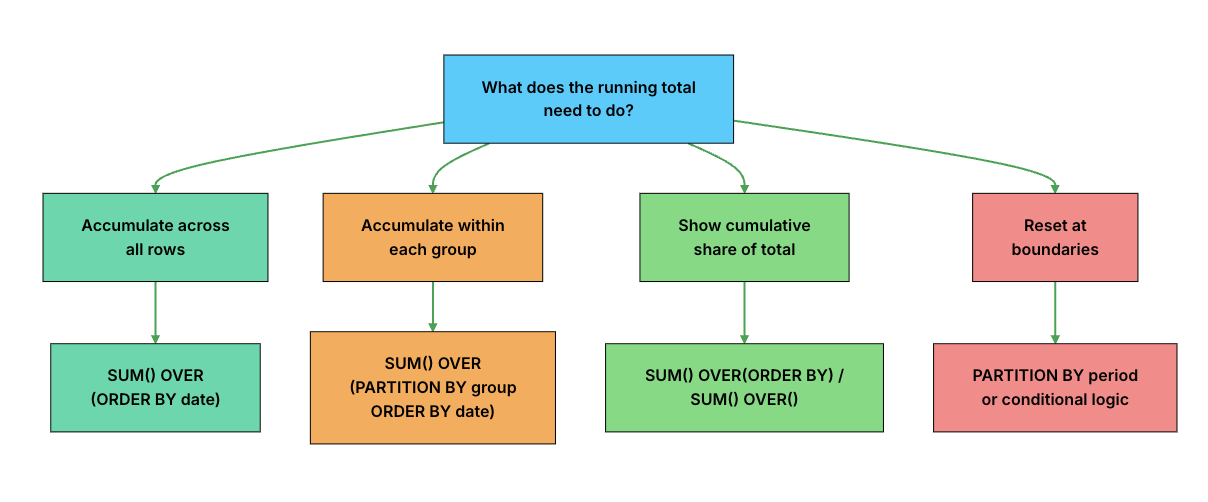

### Approach 1: Simple and Partitioned Running Totals

CTE pre-aggregates to one row per day. 

```sql
WITH daily_revenue AS (
    SELECT payment_date,
           SUM(amount - COALESCE(refund_amount, 0)) AS net_revenue
    FROM payments
    WHERE status = 'completed'
    GROUP BY payment_date
)
SELECT payment_date,
       net_revenue,
       SUM(net_revenue) OVER (ORDER BY payment_date) AS cumulative_revenue
FROM daily_revenue
ORDER BY payment_date;
```

**Partition by Groups:** Example - : "show the running total per country" or "per user." Add `PARTITION BY` to reset the accumulator for each group:

```sql
SUM(net_revenue) OVER (PARTITION BY country ORDER BY payment_date ) AS country_cumulative
```
**Combining Global and Partitioned Totals** - To show both the per-group running total and the global running total in the same query. 

```sql
SUM(net_revenue) OVER (PARTITION BY country ORDER BY payment_date ) AS country_cumulative,
SUM(net_revenue) OVER (ORDER BY payment_date, country ) AS global_cumulative
```

### Approach 2: Cumulative Percentage of Total

"what percentage of total streams does each artist account for, sorted from most to least popular?" It combines a running total with a grand total to produce a cumulative distribution.

```sql
WITH artist_streams AS (
    SELECT a.name AS artist,
           COUNT(*) AS stream_count
    FROM streams s
    GROUP BY a.name
)
SELECT artist,
       stream_count,
       SUM(stream_count) OVER (ORDER BY stream_count DESC) AS running_total,
       SUM(stream_count) OVER () AS grand_total,
       ROUND(
           SUM(stream_count) OVER (ORDER BY stream_count DESC)
           * 100.0
           / SUM(stream_count) OVER (),
           1
       ) AS cumulative_pct
FROM artist_streams
ORDER BY stream_count DESC;
```
**Cumulative Percentage Within Groups**

"cumulative percentage of streams per genre." Add PARTITION BY to both windows:
```sql
WITH genre_artist_streams AS (
    SELECT genre,
           artist,
    GROUP BY genre, artist
)
SELECT genre,
       artist,
       stream_count,
       ROUND(
           SUM(stream_count) OVER (
               PARTITION BY genre
               ORDER BY stream_count DESC
           ) * 100.0
           / SUM(stream_count) OVER (PARTITION BY genre),
           1
       ) AS cumulative_pct
FROM genre_artist_streams
ORDER BY genre, stream_count DESC;
```

**Using PERCENT_RANK and CUME_DIST**

CUME_DIST() returns the fraction of rows less than or equal to the current row's value:
```sql
WITH artist_streams AS (
    SELECT a.name AS artist,
           COUNT(*) AS stream_count
    FROM streams
    GROUP BY a.name
)
SELECT artist,
       stream_count,
       ROUND(CUME_DIST() OVER (ORDER BY stream_count) * 100, 1) AS cume_dist_pct
FROM artist_streams
ORDER BY stream_count DESC;
```

CUME_DIST is based on row position, not on the actual values being summed. It answers "what fraction of artists have this many streams or fewer?" rather than "what fraction of total streams does this artist represent?" 

### Approach 3: Resetting Running Totals at Boundaries
Instead of accumulating from the first row forever, the running total resets at some boundary: the start of each month, the start of each billing cycle, or whenever a condition is met.

The simplest reset is per-period: "show the running daily revenue within each month." PARTITION BY the time period:

```sql

WITH daily_revenue AS (
    SELECT payment_date,
           DATE_TRUNC('month', payment_date)::DATE AS month,
           SUM(amount - COALESCE(refund_amount, 0)) AS net_revenue
    FROM payments
    WHERE status = 'completed'
    GROUP BY payment_date
)
SELECT month,
       payment_date,
       net_revenue,
       SUM(net_revenue) OVER (
           PARTITION BY month
           ORDER BY payment_date
       ) AS month_running_total
FROM daily_revenue
ORDER BY payment_date;

```
PARTITION BY month resets the running total on the first day of each new month. January's total builds up through January 25th, then February starts fresh from zero.

**Resetting on a Condition**
For example: "track each user's running payment balance, but reset to zero whenever the balance exceeds 25.00."

```sql
WITH ordered_payments AS (
    SELECT payment_id,
           user_id,
           payment_date,
           amount - COALESCE(refund_amount, 0) AS net_amount,
           ROW_NUMBER() OVER (
               PARTITION BY user_id
               ORDER BY payment_date, payment_id
           ) AS rn
    FROM payments
    WHERE status = 'completed'
),
running AS (
    -- Base case: first payment per user
    SELECT payment_id, user_id, payment_date, net_amount, rn,
           net_amount AS running_total,
           1 AS reset_group
    FROM ordered_payments
    WHERE rn = 1

    UNION ALL

    -- Recursive step: add next payment, reset if threshold exceeded
    SELECT o.payment_id, o.user_id, o.payment_date, o.net_amount, o.rn,
           CASE
               WHEN r.running_total > 25.00
               THEN o.net_amount
               ELSE r.running_total + o.net_amount
           END AS running_total,
           CASE
               WHEN r.running_total > 25.00
               THEN r.reset_group + 1
               ELSE r.reset_group
           END AS reset_group
    FROM ordered_payments o
    JOIN running r
        ON r.user_id = o.user_id
       AND r.rn = o.rn - 1
)
SELECT payment_id, user_id, payment_date, net_amount,
       running_total, reset_group
FROM running
ORDER BY user_id, payment_date, payment_id;
```

<a id="gaps-in-squences"></a>

## Gaps in Sequences
[↑ Back to top](#toc)

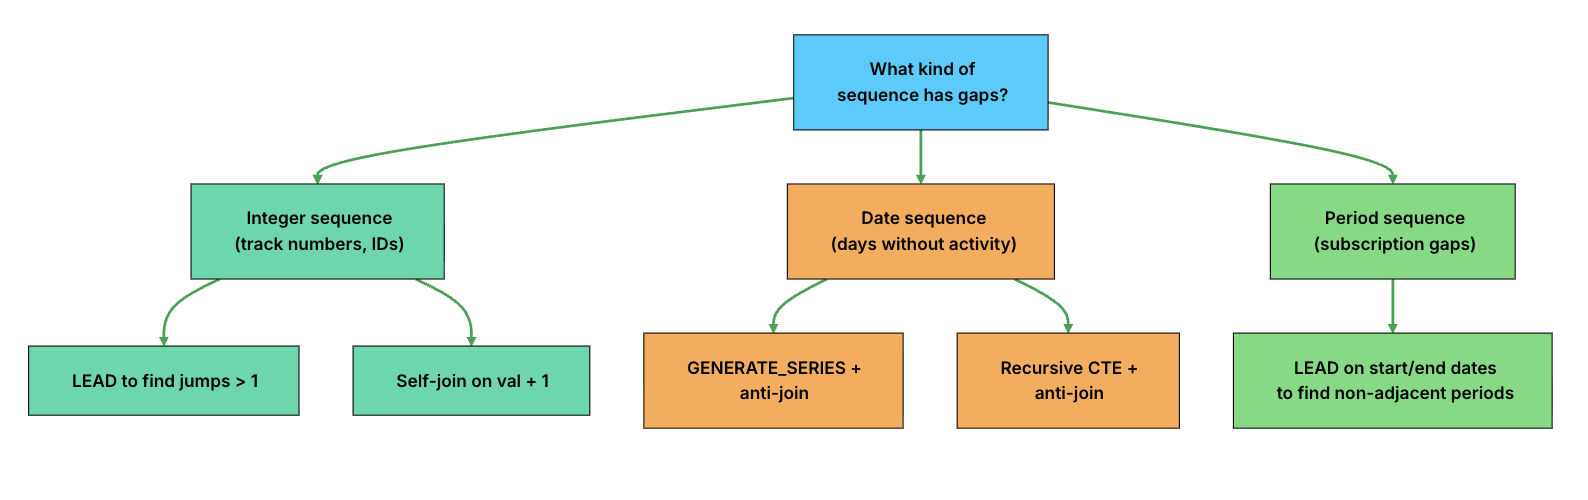

### Approach 1: LEAD/LAG

**Numeric Gaps with LEAD** Suppose you need to find missing track numbers within each album. LEAD looks at the next row's value within the same partition:

```sql
WITH sequenced AS (
    SELECT album_id,
           track_number,
           LEAD(track_number) OVER (
               PARTITION BY album_id
               ORDER BY track_number
           ) AS next_track_number
    FROM tracks
    -- give the next track numner in the album
)
SELECT album_id,
       track_number AS gap_after,
       next_track_number AS gap_before,
       next_track_number - track_number - 1 AS missing_count
FROM sequenced
WHERE next_track_number - track_number > 1;
-- to find gap
```
If you need the actual missing values (not just "there's a gap between 2 and 4"), you'll need the GENERATE_SERIES approach covered later.

**Date Gaps with LAG**
```sql
WITH user_active_days AS (
    SELECT user_id,
           started_at::DATE AS active_date
    FROM streams
    GROUP BY user_id, started_at::DATE
),
with_previous AS (
    SELECT user_id,
           active_date,
           LAG(active_date) OVER (
               PARTITION BY user_id
               ORDER BY active_date
           ) AS prev_active_date
    FROM user_active_days
)
SELECT user_id,
       prev_active_date AS last_active,
       active_date AS next_active,
       active_date - prev_active_date - 1 AS days_missing
FROM with_previous
WHERE active_date - prev_active_date > 1;
```


LEAD ->	Forward	-> "How far until the next value?"
LAG -> Backward -> "How far since the previous value?"

LEAD/LAG also only works when the sequence column already exists in the data. If you need to check a date range where no rows exist at all (say, a brand new user with zero streams during the range), there's nothing for LEAD/LAG to compare. You need a reference sequence to join against.




### Approach 2: Self-Join

```sql
SELECT t1.album_id,
       t1.track_number AS gap_after
FROM tracks t1
LEFT JOIN tracks t2
    ON t1.album_id = t2.album_id
   AND t2.track_number = t1.track_number + 1
WHERE t2.track_number IS NULL
  AND t1.track_number < (
      SELECT MAX(track_number)
      FROM tracks t3
      WHERE t3.album_id = t1.album_id
  );
```

The LEFT JOIN looks for a track with track_number + 1 in the same album. When no match exists (t2.track_number IS NULL), there's a gap. The subquery filter excludes the last track in each album, since there's nothing after it to be missing.


### Approach 3: GENERATE_SERIES

When the question asks "which dates had no streams?" or "list every missing track number," you need to generate the complete expected sequence and compare it to what actually exists.

```sql
WITH all_dates AS (
    SELECT d::DATE AS date
    FROM GENERATE_SERIES(
        '2024-01-01'::DATE,
        '2024-01-14'::DATE,
        '1 day'::INTERVAL
    ) AS d
),
active_dates AS (
    SELECT DISTINCT started_at::DATE AS date
    FROM streams
)
SELECT a.date AS missing_date
FROM all_dates a
LEFT JOIN active_dates s ON s.date = a.date
WHERE s.date IS NULL
ORDER BY a.date;
```

The LEFT JOIN with a NULL check is an anti-join pattern: "give me everything from the left side that has no match on the right side." You could also write it with NOT EXISTS:

```sql
SELECT a.date AS missing_date
FROM all_dates a
WHERE NOT EXISTS (
    SELECT 1
    FROM streams s
    WHERE s.started_at::DATE = a.date
)
ORDER BY a.date;
```


<a id="funnel-analysis-cohorts"></a>

## Funnel Analysis, Cohorts, and Retention
[↑ Back to top](#toc)

How do users move through a conversion pipeline? How does behavior change over time for different groups of users? And which marketing touchpoint deserves credit for a conversion?

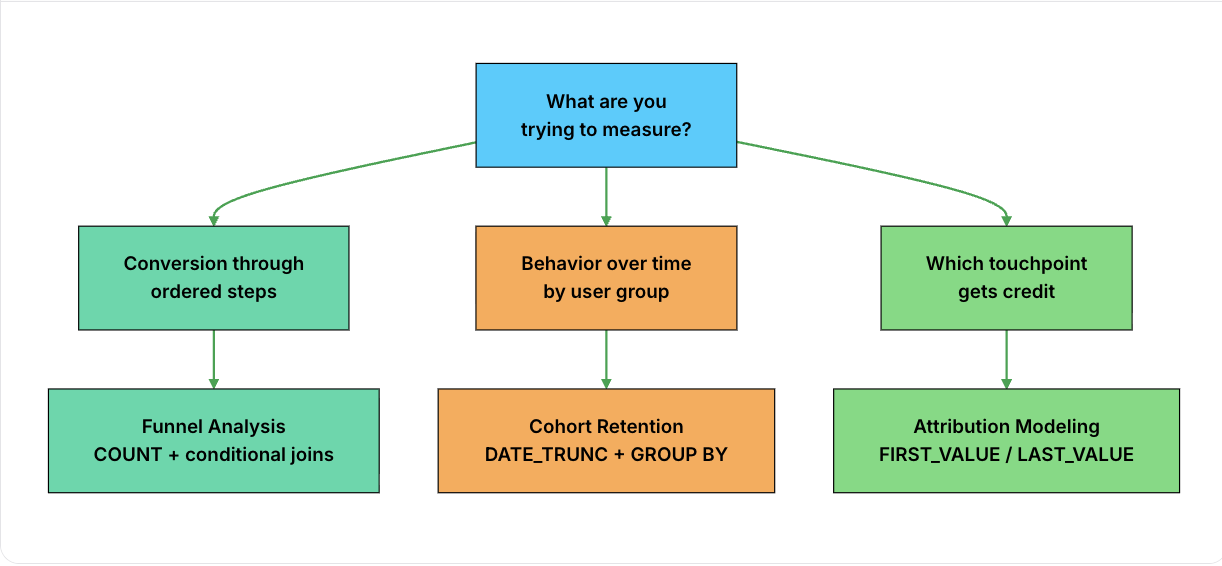

<a id="median-percentile-calc"></a>

## Median and Percentile Calculations
[↑ Back to top](#toc)


### Approach 1: PERCENTILE_CONT and PERCENTILE_DISC

PERCENTILE_CONT(0.5) computes the continuous percentile. If the 50th percentile falls between two values, it interpolates. For example, if the two middle values in a sorted list are 180 and 210, the continuous median is 195 (the average of the two).

PERCENTILE_DISC(0.5) computes the discrete percentile. It always returns an actual value from the dataset. Instead of interpolating, it picks the first value whose cumulative position meets or exceeds the requested percentile.

```sql
SELECT
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY duration_seconds) AS median_cont,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY duration_seconds) AS median_disc
FROM tracks;
```

